# 04 — Expérience complémentaire : prévision de la consommation électrique à J+7

## Objectif

Ce notebook reprend la logique des notebooks de préparation des variables et de modélisation à J+1,
mais en déplaçant l'horizon de prévision à **7 jours**.

L'objectif n'est pas de remplacer le modèle principal à J+1, mais de mesurer la dégradation des
performances lorsque l'horizon de prévision est fortement allongé.

La cible correspond à la consommation électrique observée exactement **7 jours après l'instant `t`**.

La méthodologie reprend les mêmes principes :

- préparation temporelle des données ;
- construction de variables historiques ;
- séparation chronologique train / validation / test ;
- baseline naïve ;
- entraînement d'un modèle HistGradientBoosting ;
- sélection de variables par permutation importance ;
- optimisation avec validation croisée temporelle ;
- évaluation finale sur 2025.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV


## 1. Chargement des données brutes

Le notebook utilise le même fichier éCO2mix que le notebook de préparation à J+1.


In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "eco2mix-regional-cons-def.csv"
)

df = pd.read_csv(
    RAW_PATH,
    sep=";",
    na_values=["ND", "N/A", ""],
    low_memory=False
)

df.shape


(2839104, 32)

In [3]:
df["Date - Heure"] = pd.to_datetime(
    df["Date - Heure"],
    utc=True,
    errors="coerce"
)

df = df[
    (df["Région"] == "Nouvelle-Aquitaine")
    & (df["Date - Heure"].dt.year >= 2019)
].copy()

df = df.sort_values("Date - Heure").reset_index(drop=True)

if "Column 30" in df.columns:
    df = df.drop(columns=["Column 30"])

df = df.drop_duplicates(
    subset=["Région", "Date - Heure"],
    keep="last"
).copy()

df.shape


(131406, 31)

## 2. Construction de la cible à J+7

La cible n'est pas construite avec `shift(-336)` mais par correspondance explicite de timestamp.
Cela évite qu'une éventuelle rupture temporelle décale artificiellement la cible.

Pour chaque instant `t`, on recherche donc la consommation observée exactement **7 jours plus tard**.


In [4]:
target_lookup = (
    df[["Date - Heure", "Consommation (MW)"]]
    .copy()
)

target_lookup["Date - Heure"] = (
    target_lookup["Date - Heure"] - pd.Timedelta(days=7)
)

target_lookup = target_lookup.rename(
    columns={"Consommation (MW)": "target_consumption_t_plus_7d"}
)

df = df.merge(
    target_lookup,
    on="Date - Heure",
    how="left"
)

df[["Date - Heure", "Consommation (MW)", "target_consumption_t_plus_7d"]].head()


,Date - Heure,Consommation (MW),target_consumption_t_plus_7d
0,2019-01-01 00:00:00+00:00,6391.0,6731.0
1,2019-01-01 00:30:00+00:00,6543.0,6857.0
2,2019-01-01 01:00:00+00:00,6341.0,6644.0
3,2019-01-01 01:30:00+00:00,6384.0,6684.0
4,2019-01-01 02:00:00+00:00,6119.0,6477.0


## 3. Construction des variables historiques

La prévision à J+7 ne doit utiliser que des informations disponibles à l'instant `t`.

Les variables historiques reprennent celles du projet principal :
consommation actuelle, lags récents, moyennes glissantes et variables calendaires.


In [5]:
consumption_by_time = (
    df.set_index("Date - Heure")["Consommation (MW)"]
)

lags = {
    "30min": pd.Timedelta(minutes=30),
    "1h": pd.Timedelta(hours=1),
    "3h": pd.Timedelta(hours=3),
    "6h": pd.Timedelta(hours=6),
    "24h": pd.Timedelta(hours=24),
    "48h": pd.Timedelta(hours=48),
    "7d": pd.Timedelta(days=7),
    "14d": pd.Timedelta(days=14),
}

for name, delta in lags.items():
    df[f"consumption_lag_{name}"] = (
        consumption_by_time
        .reindex(df["Date - Heure"] - delta)
        .to_numpy()
    )

df["consumption_t"] = df["Consommation (MW)"]


In [6]:
# Statistiques glissantes calculées uniquement avec le passé

df["consumption_roll_mean_48"] = (
    df["Consommation (MW)"]
    .shift(1)
    .rolling(window=48)
    .mean()
)

df["consumption_roll_mean_336"] = (
    df["Consommation (MW)"]
    .shift(1)
    .rolling(window=336)
    .mean()
)

df["consumption_roll_std_48"] = (
    df["Consommation (MW)"]
    .shift(1)
    .rolling(window=48)
    .std()
)

df["consumption_roll_std_336"] = (
    df["Consommation (MW)"]
    .shift(1)
    .rolling(window=336)
    .std()
)


In [7]:
dt = df["Date - Heure"]

df["hour"] = dt.dt.hour
df["minute"] = dt.dt.minute
df["day_of_week"] = dt.dt.dayofweek
df["month"] = dt.dt.month
df["day_of_year"] = dt.dt.dayofyear
df["is_weekend"] = (dt.dt.dayofweek >= 5).astype(int)

df["half_hour_slot"] = (
    df["hour"] * 2
    + (df["minute"] // 30)
)

df["hour_sin"] = np.sin(2 * np.pi * df["half_hour_slot"] / 48)
df["hour_cos"] = np.cos(2 * np.pi * df["half_hour_slot"] / 48)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


In [8]:
df["consumption_diff_1"] = (
    df["consumption_t"]
    - df["consumption_lag_30min"]
)

df["consumption_diff_24h"] = (
    df["consumption_t"]
    - df["consumption_lag_24h"]
)

df["consumption_diff_7d"] = (
    df["consumption_t"]
    - df["consumption_lag_7d"]
)


## 4. Dataset de modélisation

On conserve uniquement les variables numériques construites à partir d'informations disponibles à `t`.


In [9]:
feature_cols = [
    "consumption_t",
    "consumption_lag_30min",
    "consumption_lag_1h",
    "consumption_lag_3h",
    "consumption_lag_6h",
    "consumption_lag_24h",
    "consumption_lag_48h",
    "consumption_lag_7d",
    "consumption_lag_14d",
    "consumption_roll_mean_48",
    "consumption_roll_mean_336",
    "consumption_roll_std_48",
    "consumption_roll_std_336",
    "consumption_diff_1",
    "consumption_diff_24h",
    "consumption_diff_7d",
    "hour",
    "minute",
    "day_of_week",
    "month",
    "day_of_year",
    "is_weekend",
    "half_hour_slot",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

model_df = df[
    ["Date - Heure"]
    + feature_cols
    + ["target_consumption_t_plus_7d"]
].dropna().copy()

print("Dataset :", model_df.shape)
print("Début :", model_df["Date - Heure"].min())
print("Fin :", model_df["Date - Heure"].max())


Dataset : (130286, 31)
Début : 2019-01-15 00:00:00+00:00
Fin : 2026-06-23 21:30:00+00:00


## 5. Séparation chronologique

On conserve la même logique que pour le modèle J+1 :

- entraînement : 2019 à 2023 ;
- validation : 2024 ;
- test final : 2025.

Le jeu de test ne doit pas servir au choix des variables ou des hyperparamètres.


In [10]:
train = model_df[
    model_df["Date - Heure"] < "2024-01-01"
].copy()

validation = model_df[
    (model_df["Date - Heure"] >= "2024-01-01")
    & (model_df["Date - Heure"] < "2025-01-01")
].copy()

test = model_df[
    (model_df["Date - Heure"] >= "2025-01-01")
    & (model_df["Date - Heure"] < "2026-01-01")
].copy()

for name, subset in [
    ("Train", train),
    ("Validation", validation),
    ("Test", test),
]:
    print(
        name,
        subset.shape,
        subset["Date - Heure"].min(),
        subset["Date - Heure"].max()
    )


Train (86886, 31) 2019-01-15 00:00:00+00:00 2023-12-31 23:30:00+00:00
Validation (17550, 31) 2024-01-01 00:00:00+00:00 2024-12-31 23:30:00+00:00
Test (17502, 31) 2025-01-01 00:00:00+00:00 2025-12-31 23:30:00+00:00


In [11]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


## 6. Baseline J+7

Pour une prévision à sept jours, la baseline la plus naturelle consiste à considérer que
la consommation dans une semaine sera égale à la consommation actuelle.

`t` et `t + 7 jours` correspondent en principe au même jour de la semaine et au même créneau horaire.


In [12]:
y_val = validation["target_consumption_t_plus_7d"]

baseline_pred = validation["consumption_t"]

baseline_results = regression_metrics(
    y_val,
    baseline_pred
)

baseline_results


{'MAE': 418.1596581196581, 'RMSE': 613.6997337386446, 'R2': 0.6204257235304087}

## 7. HistGradientBoosting sans optimisation

On entraîne d'abord le même type de modèle que pour l'expérience à J+1, sans optimisation.


In [13]:
X_train = train[feature_cols]
y_train = train["target_consumption_t_plus_7d"]

X_val = validation[feature_cols]
y_val = validation["target_consumption_t_plus_7d"]

hgb = HistGradientBoostingRegressor(
    random_state=42
)

hgb.fit(X_train, y_train)

val_pred = hgb.predict(X_val)

hgb_results = regression_metrics(
    y_val,
    val_pred
)

pd.DataFrame([
    {"model": "Baseline J+7", **baseline_results},
    {"model": "HGB - toutes variables", **hgb_results},
])


,model,MAE,RMSE,R2
0,Baseline J+7,418.159658,613.699734,0.620426
1,HGB - toutes variables,361.036354,514.150580,0.733581


In [14]:
mae_gain_vs_baseline = (
    baseline_results["MAE"] - hgb_results["MAE"]
) / baseline_results["MAE"] * 100

print(f"Gain MAE vs baseline : {mae_gain_vs_baseline:.2f} %")


Gain MAE vs baseline : 13.66 %


## 8. Sélection des variables par permutation importance

Comme dans le modèle J+1, on mesure la contribution prédictive des variables sur le jeu de validation.


In [15]:
perm_importance = permutation_importance(
    hgb,
    X_val,
    y_val,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std,
}).sort_values(
    "importance",
    ascending=False
)

importance_df.head(20)


,feature,importance,std
0,consumption_t,269.023028,1.251083
28,month_cos,43.684501,0.642911
7,consumption_lag_7d,27.653126,1.015410
20,day_of_year,23.669757,0.754964
10,consumption_roll_mean_336,19.662349,0.369155
12,consumption_roll_std_336,12.182394,0.357776
8,consumption_lag_14d,10.188438,0.246402
9,consumption_roll_mean_48,8.029677,0.250895
18,day_of_week,6.067079,0.258506
16,hour,4.099746,0.303972


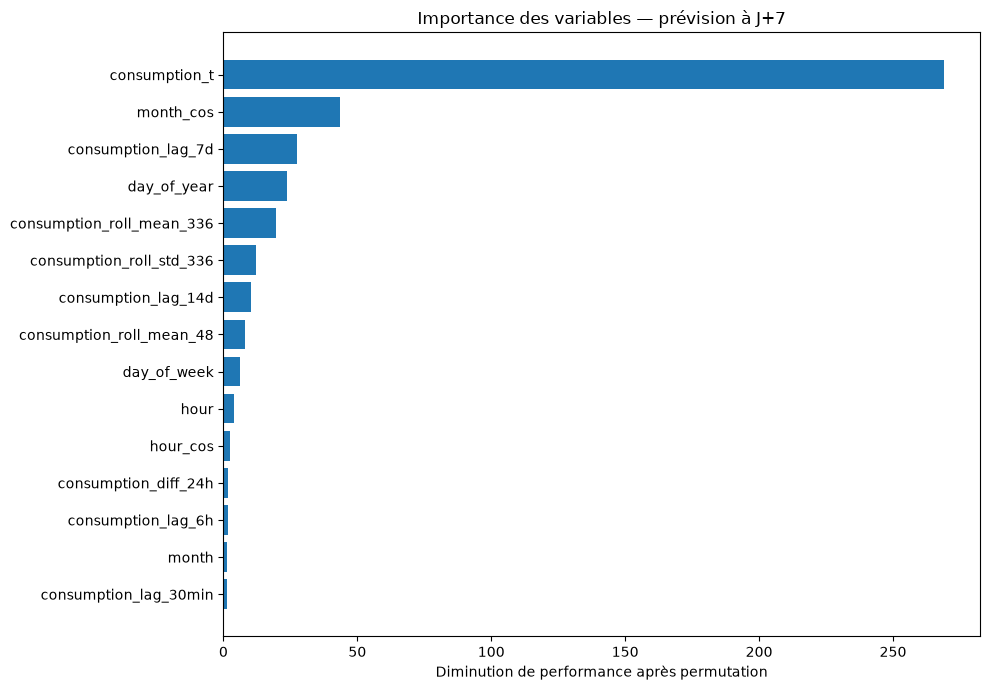

In [16]:
top_features = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)
plt.xlabel("Diminution de performance après permutation")
plt.title("Importance des variables — prévision à J+7")
plt.tight_layout()
plt.show()


In [17]:
selected_features = (
    importance_df
    .head(10)["feature"]
    .tolist()
)

selected_features


['consumption_t',
 'month_cos',
 'consumption_lag_7d',
 'day_of_year',
 'consumption_roll_mean_336',
 'consumption_roll_std_336',
 'consumption_lag_14d',
 'consumption_roll_mean_48',
 'day_of_week',
 'hour']

In [18]:
hgb_selected = HistGradientBoostingRegressor(
    random_state=42
)

hgb_selected.fit(
    X_train[selected_features],
    y_train
)

selected_pred = hgb_selected.predict(
    X_val[selected_features]
)

selected_results = regression_metrics(
    y_val,
    selected_pred
)

pd.DataFrame([
    {"model": "HGB - toutes variables", **hgb_results},
    {"model": "HGB - top 10 variables", **selected_results},
])


,model,MAE,RMSE,R2
0,HGB - toutes variables,361.036354,514.150580,0.733581
1,HGB - top 10 variables,362.239396,516.911928,0.730711


## 9. Optimisation

L'horizon est de 7 jours. La validation croisée temporelle utilise donc un `gap=336`
(336 demi-heures = 7 jours) afin d'éviter que les cibles des dernières observations
d'entraînement ne débordent dans la fenêtre de validation.


In [19]:
tscv = TimeSeriesSplit(
    n_splits=4,
    gap=336
)

param_distributions = {
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "max_iter": [100, 200, 300],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [10, 20, 40, 60],
    "l2_regularization": [0.0, 0.1, 1.0, 5.0],
}

search = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(
        random_state=42
    ),
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(
    X_train[selected_features],
    y_train
)

print("Meilleurs paramètres :")
print(search.best_params_)

print("\nMAE moyenne en validation croisée :")
print(-search.best_score_)


Fitting 4 folds for each of 30 candidates, totalling 120 fits
Meilleurs paramètres :
{'min_samples_leaf': 60, 'max_leaf_nodes': 15, 'max_iter': 200, 'learning_rate': 0.03, 'l2_regularization': 5.0}

MAE moyenne en validation croisée :
371.81816343852597


In [20]:
best_hgb_week = search.best_estimator_

optimized_val_pred = best_hgb_week.predict(
    X_val[selected_features]
)

optimized_val_results = regression_metrics(
    y_val,
    optimized_val_pred
)

pd.DataFrame([
    {"model": "HGB top 10 - défaut", **selected_results},
    {"model": "HGB top 10 - optimisé", **optimized_val_results},
])


,model,MAE,RMSE,R2
0,HGB top 10 - défaut,362.239396,516.911928,0.730711
1,HGB top 10 - optimisé,353.742099,501.179150,0.746854


## 10. Évaluation finale sur 2025

Les hyperparamètres étant maintenant figés, on évalue le modèle sur le jeu de test 2025.


In [21]:
X_test = test[selected_features]
y_test = test["target_consumption_t_plus_7d"]

test_pred = best_hgb_week.predict(X_test)

test_results = regression_metrics(
    y_test,
    test_pred
)

baseline_test_pred = test["consumption_t"]

baseline_test_results = regression_metrics(
    y_test,
    baseline_test_pred
)

final_results = pd.DataFrame([
    {"model": "Baseline J+7", **baseline_test_results},
    {"model": "HGB J+7 optimisé", **test_results},
])

final_results


,model,MAE,RMSE,R2
0,Baseline J+7,459.405782,673.337286,0.638496
1,HGB J+7 optimisé,397.754820,552.633432,0.756487


In [22]:
mae_gain_test = (
    baseline_test_results["MAE"]
    - test_results["MAE"]
) / baseline_test_results["MAE"] * 100

rmse_gain_test = (
    baseline_test_results["RMSE"]
    - test_results["RMSE"]
) / baseline_test_results["RMSE"] * 100

print(f"Gain MAE sur test : {mae_gain_test:.2f} %")
print(f"Gain RMSE sur test : {rmse_gain_test:.2f} %")


Gain MAE sur test : 13.42 %
Gain RMSE sur test : 17.93 %


## 11. Analyse visuelle

On observe une courte période afin de vérifier si le modèle suit correctement la dynamique réelle.


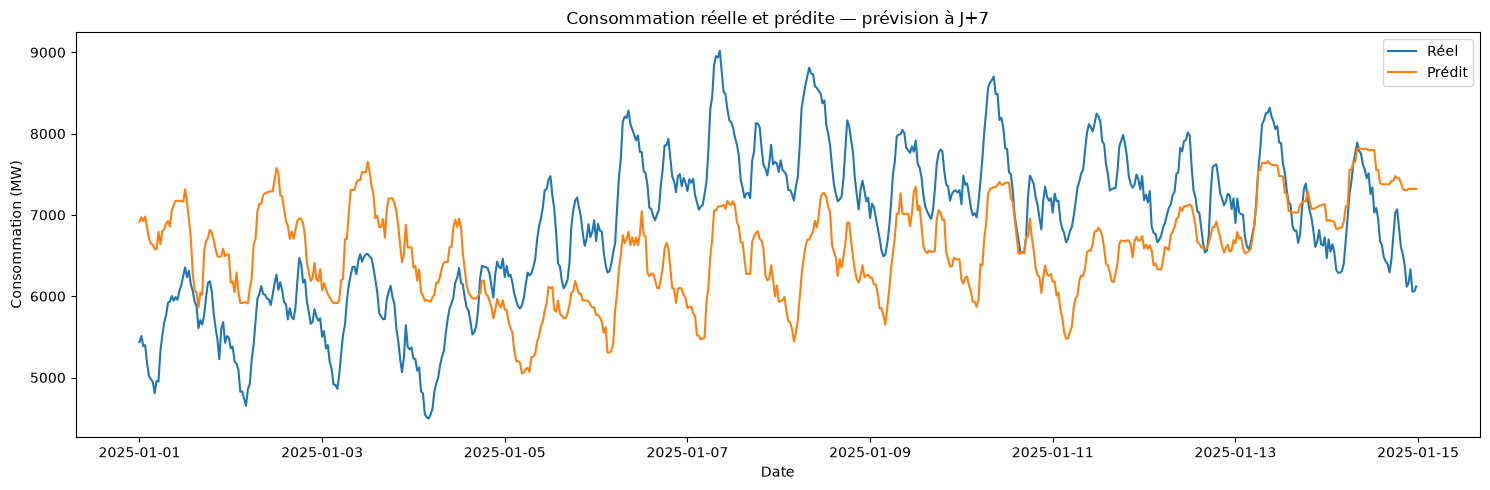

In [23]:
test_results_df = test[
    ["Date - Heure"]
].copy()

test_results_df["y_true"] = y_test.values
test_results_df["y_pred"] = test_pred
test_results_df["abs_error"] = (
    test_results_df["y_true"]
    - test_results_df["y_pred"]
).abs()

sample_period = test_results_df[
    (test_results_df["Date - Heure"] >= "2025-01-01")
    & (test_results_df["Date - Heure"] < "2025-01-15")
]

plt.figure(figsize=(15, 5))
plt.plot(
    sample_period["Date - Heure"],
    sample_period["y_true"],
    label="Réel"
)
plt.plot(
    sample_period["Date - Heure"],
    sample_period["y_pred"],
    label="Prédit"
)
plt.title("Consommation réelle et prédite — prévision à J+7")
plt.xlabel("Date")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
threshold = y_test.quantile(0.90)

high_consumption = test_results_df[
    test_results_df["y_true"] >= threshold
]

high_consumption_results = regression_metrics(
    high_consumption["y_true"],
    high_consumption["y_pred"]
)

high_consumption_results


{'MAE': 858.4092865255318,
 'RMSE': 999.4699306537781,
 'R2': -1.3189520929337508}

## Conclusion à compléter après exécution

Cette expérience permet de comparer l'horizon J+7 au modèle principal à J+1.

À commenter après exécution :

- niveau absolu de MAE / RMSE / R² ;
- gain du modèle par rapport à la baseline J+7 ;
- dégradation éventuelle par rapport au modèle J+1 ;
- comportement lors des pics de consommation ;
- pertinence ou non d'un horizon de sept jours pour le cas d'usage.

Si les performances se dégradent fortement, ce résultat n'est pas un échec :
il montre expérimentalement que l'allongement de l'horizon réduit la prédictibilité
à partir des seules variables historiques et calendaires disponibles.
